<a href="https://colab.research.google.com/github/karinfaraujo/fraud-detection-anomaly-analysis-python/blob/main/fraud-detection-anomaly-analysis-python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud Detection and Anomaly Analysis in Financial Transactions

## 1. Business Problem

The objective of this project is to build a machine learning model capable of identifying potentially fraudulent financial transactions.

Fraud detection is a highly imbalanced classification problem, where fraudulent cases represent only a very small percentage of all transactions.

## 2. Import Libraries

In [1]:
# Importing essential libraries for data analysis and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.utils import resample
from xgboost import XGBClassifier

import shap

## 3. Load Data

In [2]:
# Data Loading
# In this step, the dataset is loaded and the initial structure is inspected.

In [3]:
# Reading the dataset
df = pd.read_csv("creditcard.csv")

# Displaying the first rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## 4. Check Imbalance

In [5]:
# Class Distribution Analysis
# Since fraud detection is usually a rare event problem, it is important to verify the class distribution.

In [6]:
# Checking target variable distribution
df['Class'].value_counts()

,count
Class,
0,284315
1,492


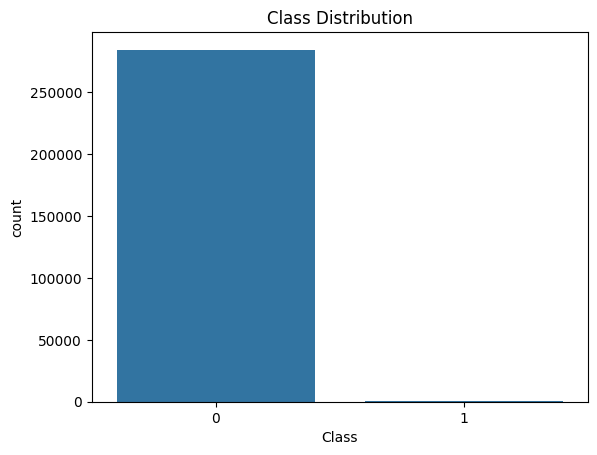

In [7]:
# Plotting class imbalance
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

## 5. Feature Engineering

In [8]:
# New variables are created to improve model performance and capture hidden patterns in the data.

In [9]:
# Creating log transformation for transaction amount
df['Amount_log'] = np.log1p(df['Amount'])

# Extracting hour from time
df['Hour'] = df['Time'] // 3600

## 6. Modelling

In [10]:
# Baseline Model - Logistic Regression
# A baseline model is created to establish an initial performance benchmark.

In [11]:
# Training baseline model
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Data Balancing

In [12]:
# The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of all observations.
# This imbalance can lead the model to favor the majority class, resulting in poor detection of fraud cases.
# To address this issue, data balancing techniques such as oversampling are applied
# to increase the representation of the minority class and improve the model's ability to identify fraudulent transactions.

In [13]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

fraud_upsampled = resample(
    fraud,
    replace=True,
    n_samples=len(normal),
    random_state=42
)

balanced_df = pd.concat([normal, fraud_upsampled])

## 8. Advanced Model (XGBoost)

In [14]:
# After establishing a baseline model with Logistic Regression, a more advanced machine learning model is applied.
# XGBoost is an ensemble learning algorithm based on gradient boosting decision trees.
# It is widely used for classification problems due to its high predictive performance,
# ability to capture non-linear relationships, and robustness when dealing with complex datasets.

In [15]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.79      0.82        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## 9. Feature Importance

In [16]:
# Feature importance analysis helps identify which variables contribute the most to the model's predictions.
# This step is essential for understanding the main factors associated with fraudulent transactions
# and provides valuable business insights beyond predictive performance.

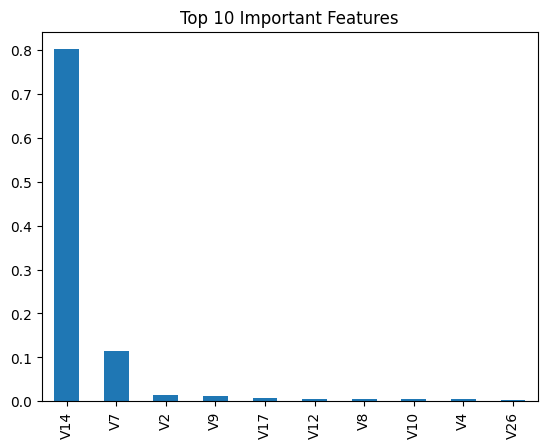

In [17]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

## 10. Hyperparameter Tuning

In [18]:
# Hyperparameter tuning is performed to optimize the model's performance.
# Different combinations of parameters such as learning rate, tree depth, and
# number of estimators are tested to identify the configuration that provides the best predictive results.

In [19]:
params = {
    'max_depth': [3, 5],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(xgb, params, cv=3, scoring='roc_auc')
grid.fit(X_train, y_train)

grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

## 11. SHAP (SHapley Additive exPlanations)

In [20]:
# Model Explainability
# SHAP values are used to interpret which variables contribute the most to fraud prediction.

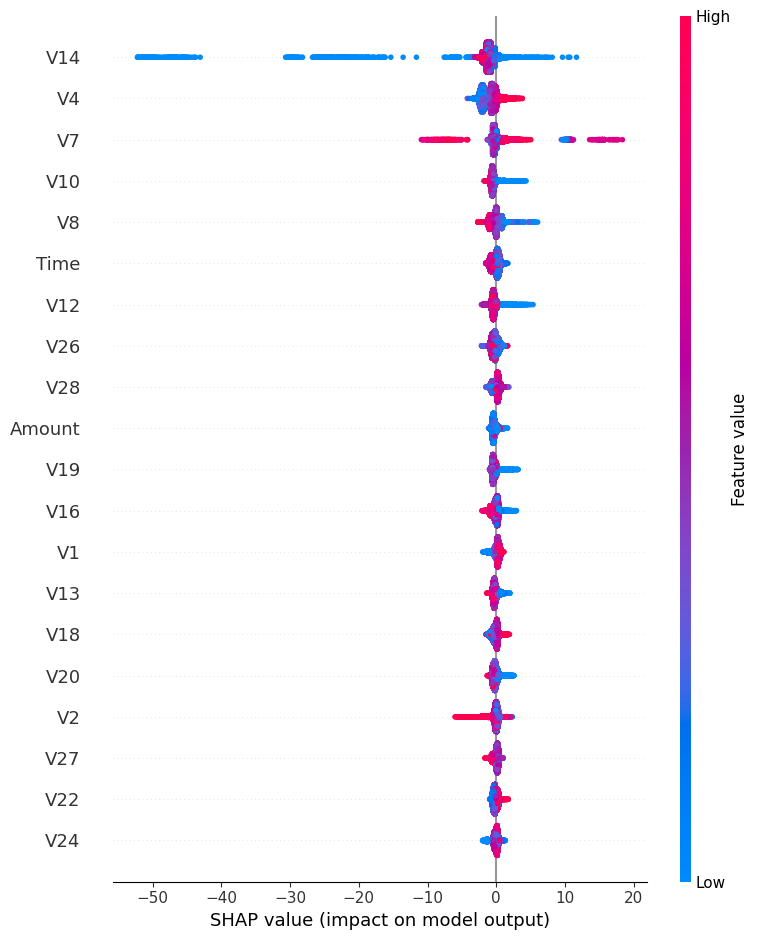

In [21]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)